In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

PROJECT_ROOT = Path(r"C:\sem5\edi\AllergyGuard")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

print("Project:", PROJECT_ROOT)
print("Raw data:", DATA_RAW)
print("Python environment ready.")

Project: C:\sem5\edi\AllergyGuard
Raw data: C:\sem5\edi\AllergyGuard\data\raw
Python environment ready.


In [2]:
image_files = sorted([
    p for p in DATA_RAW.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
])

print("Images found:")
print("=" * 80)

for p in image_files:
    print(p.name)

print("\nTotal images:", len(image_files))

Images found:
food_ingredients.webp
oreo.jpg
random.jpg
restaurant.jpg
test_image.jpg

Total images: 5


In [3]:
import paddleocr
import paddle

print("PaddleOCR version:", paddleocr.__version__)
print("PaddlePaddle version:", paddle.__version__)

PaddleOCR version: 3.7.0
PaddlePaddle version: 3.3.0


In [4]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang="en",
    enable_mkldnn=False
)

print("PaddleOCR initialized successfully.")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\hp\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\hp\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\hp\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\hp\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\

PaddleOCR initialized successfully.


In [5]:
image_path = DATA_RAW / "food_ingredients.webp"

print("Testing image:")
print(image_path)

Testing image:
C:\sem5\edi\AllergyGuard\data\raw\food_ingredients.webp


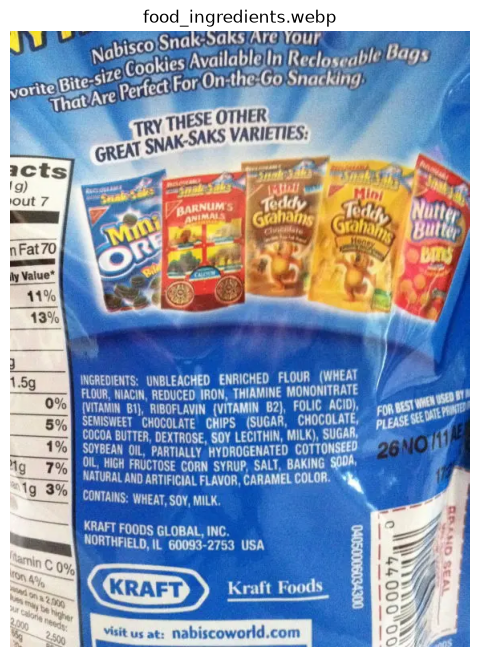

In [6]:
img = Image.open(image_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("food_ingredients.webp")
plt.show()

In [7]:
result = ocr.predict(
    str(image_path),
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    text_det_limit_side_len=960
)

print("OCR completed.")
print("Result type:", type(result))

OCR completed.
Result type: <class 'list'>


In [16]:
print(result)

[{'input_path': 'C:\\sem5\\edi\\AllergyGuard\\data\\raw\\test_image.jpg', 'page_index': None, 'doc_preprocessor_res': {'output_img': array([[[173, ..., 205],
        ...,
        [223, ..., 231]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(280, 464, 3), dtype=uint8)}, 'dt_polys': [array([[152, 265],
       ...,
       [152, 276]], shape=(4, 2), dtype=int16)], 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': False}, 'text_det_params': {'limit_side_len': 960, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['shutterstock.com·2729775773'], 'rec_scores': [0.9852908253669739], 'rec_polys': [array([[152, 265],
       ...,
       [152, 276]], shape=(4, 2), dtype=int16)], 'vis_fonts': [<paddlex.utils.fonts.Font object at 0x000001B967F575C0>], 'textline_orientation_angles': [-1], 

In [17]:
res = result[0]

texts = res.get("rec_texts", [])
scores = res.get("rec_scores", [])

print("Number of OCR regions:", len(texts))

ocr_data = pd.DataFrame({
    "text": texts,
    "confidence": scores
})

display(ocr_data)

Number of OCR regions: 1


,text,confidence
0,shutterstock.com·2729775773,0.985291


In [11]:
if len(ocr_data) > 0:
    print("OCR regions:", len(ocr_data))
    print("Average confidence:", round(ocr_data["confidence"].mean(), 4))
    print("Minimum confidence:", round(ocr_data["confidence"].min(), 4))
    print("Maximum confidence:", round(ocr_data["confidence"].max(), 4))
else:
    print("No OCR text detected.")

OCR regions: 87
Average confidence: 0.9545
Minimum confidence: 0.326
Maximum confidence: 1.0


In [12]:
full_ocr_text = " ".join(
    str(text).strip()
    for text in texts
    if str(text).strip()
)

print(full_ocr_text)

Bags TRY THESE OTHER GREAT SNAK-SAKS VARIETIES: acts g) SnakeSaks 131AI Mini out 7 Snako-Saks Teddy Teddy Nutter BARNUM'S ANIMALS Grahams Grahams Butter Mini n Fat 70 RI BmS ly Value* Bile 11% 13% 9 1.5g INGREDIENTS: UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, NIACIN, REDUCED IRON, THIAMINE MONONITRATE 0% {VITAMIN B1}, RIBOFLAVIN (VITAMIN B2}, FOLIC ACID), FOR BEST WHEN USED BY 5% SEMISWEET CHOCOLATE CHIPS (SUGAR, CHOCOLATÉ, PLEASE SEE DATE PRINTED COCOA BUTTER, DEXTROSE, SOY LECITHIN, MILK), SUGAR, 1% SOYBEAN OIL, PARTIALLY HYDROGENATED COTTONSEED 26NO/11AE 1g 7% OIL, HIGH FRUCTOSE CORN SYRUP, SALT, BAKING SODA, NATURAL AND ARTIFICIAL FLAVOR, CARAMEL COLOR. 1g 3% CONTAINS: WHEAT, SOY, MILK. BRAND SEAL KRAFT FOODS GLOBAL, INC. 04050006034300 0 NORTHFIELD, IL 60093-2753 USA tamin C 0% 44000 ron 4% KRAFT Dased on a 2,000 Kraft Foods lues may be higher cour calorie needs: 2,000 65g 2,500 visit us at: nabiscoworld.com 00


In [13]:
full_ocr_text = " ".join(
    str(text).strip()
    for text in texts
    if str(text).strip()
)

print(full_ocr_text)

Bags TRY THESE OTHER GREAT SNAK-SAKS VARIETIES: acts g) SnakeSaks 131AI Mini out 7 Snako-Saks Teddy Teddy Nutter BARNUM'S ANIMALS Grahams Grahams Butter Mini n Fat 70 RI BmS ly Value* Bile 11% 13% 9 1.5g INGREDIENTS: UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, NIACIN, REDUCED IRON, THIAMINE MONONITRATE 0% {VITAMIN B1}, RIBOFLAVIN (VITAMIN B2}, FOLIC ACID), FOR BEST WHEN USED BY 5% SEMISWEET CHOCOLATE CHIPS (SUGAR, CHOCOLATÉ, PLEASE SEE DATE PRINTED COCOA BUTTER, DEXTROSE, SOY LECITHIN, MILK), SUGAR, 1% SOYBEAN OIL, PARTIALLY HYDROGENATED COTTONSEED 26NO/11AE 1g 7% OIL, HIGH FRUCTOSE CORN SYRUP, SALT, BAKING SODA, NATURAL AND ARTIFICIAL FLAVOR, CARAMEL COLOR. 1g 3% CONTAINS: WHEAT, SOY, MILK. BRAND SEAL KRAFT FOODS GLOBAL, INC. 04050006034300 0 NORTHFIELD, IL 60093-2753 USA tamin C 0% 44000 ron 4% KRAFT Dased on a 2,000 Kraft Foods lues may be higher cour calorie needs: 2,000 65g 2,500 visit us at: nabiscoworld.com 00


Experiment 02 — Batch PaddleOCR baseline

In [14]:
batch_results = []

for image_path in image_files:

    print(f"Processing: {image_path.name}")

    try:
        result = ocr.predict(
            str(image_path),
            use_doc_orientation_classify=False,
            use_doc_unwarping=False,
            use_textline_orientation=False,
            text_det_limit_side_len=960
        )

        res = result[0]

        texts = res.get("rec_texts", [])
        scores = res.get("rec_scores", [])

        combined_text = " ".join(
            str(t).strip()
            for t in texts
            if str(t).strip()
        )

        avg_confidence = (
            float(np.mean(scores))
            if len(scores) > 0
            else 0.0
        )

        batch_results.append({
            "image": image_path.name,
            "ocr_regions": len(texts),
            "avg_confidence": avg_confidence,
            "ingredients_detected": "INGREDIENTS" in combined_text.upper(),
            "contains_detected": "CONTAINS" in combined_text.upper(),
            "ocr_text": combined_text
        })

    except Exception as e:

        batch_results.append({
            "image": image_path.name,
            "ocr_regions": 0,
            "avg_confidence": 0.0,
            "ingredients_detected": False,
            "contains_detected": False,
            "ocr_text": "",
            "error": str(e)
        })

batch_df = pd.DataFrame(batch_results)

display(batch_df)

Processing: food_ingredients.webp
Processing: oreo.jpg
Processing: random.jpg
Processing: restaurant.jpg
Processing: test_image.jpg


,image,ocr_regions,avg_confidence,ingredients_detected,contains_detected,ocr_text
0,food_ingredients.webp,87,0.954520,True,True,Bags TRY THESE OTHER GREAT SNAK-SAKS VARIETIES...
1,oreo.jpg,43,0.595417,False,False,Calories 400 S 4 10 A 18 t0 1% 5 15 7 th 40 on...
2,random.jpg,11,0.972805,True,False,* The % Daily Value (DV) tells yo INGREDIENTS:...
3,restaurant.jpg,56,0.981894,False,False,Starter International Chilli Paneer INR 675 Co...
4,test_image.jpg,1,0.985291,False,False,shutterstock.com·2729775773


In [ ]:
paddleocr_baseline_path = DATA_RAW / "paddleocr_baseline_results.csv"

batch_df.to_csv(
    paddleocr_baseline_path,
    index=False
)

print("Saved:")
print(paddleocr_baseline_path)

In [ ]:
for _, row in batch_df.iterrows():

    print("\n" + "=" * 100)
    print("IMAGE:", row["image"])
    print("=" * 100)

    print(row["ocr_text"])

In [18]:
def extract_ingredient_section(text):
    """
    Extract text between INGREDIENTS and CONTAINS.
    If CONTAINS is absent, extract from INGREDIENTS to the end.
    """

    text_upper = text.upper()

    start = text_upper.find("INGREDIENTS")

    if start == -1:
        return ""

    start = start + len("INGREDIENTS")

    end = text_upper.find("CONTAINS", start)

    if end == -1:
        end = len(text)

    ingredient_text = text[start:end]

    # Basic cleanup
    ingredient_text = re.sub(r"\s+", " ", ingredient_text)
    ingredient_text = ingredient_text.strip(" :.-")

    return ingredient_text

In [19]:
food_row = batch_df[
    batch_df["image"] == "food_ingredients.webp"
].iloc[0]

ingredient_text = extract_ingredient_section(
    food_row["ocr_text"]
)

print("EXTRACTED INGREDIENT SECTION")
print("=" * 80)
print(ingredient_text)

EXTRACTED INGREDIENT SECTION
UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, NIACIN, REDUCED IRON, THIAMINE MONONITRATE 0% {VITAMIN B1}, RIBOFLAVIN (VITAMIN B2}, FOLIC ACID), FOR BEST WHEN USED BY 5% SEMISWEET CHOCOLATE CHIPS (SUGAR, CHOCOLATÉ, PLEASE SEE DATE PRINTED COCOA BUTTER, DEXTROSE, SOY LECITHIN, MILK), SUGAR, 1% SOYBEAN OIL, PARTIALLY HYDROGENATED COTTONSEED 26NO/11AE 1g 7% OIL, HIGH FRUCTOSE CORN SYRUP, SALT, BAKING SODA, NATURAL AND ARTIFICIAL FLAVOR, CARAMEL COLOR. 1g 3%


In [20]:
def extract_contains_statement(text):
    """
    Extract allergen names appearing after CONTAINS.
    """

    match = re.search(
        r"CONTAINS\s*:\s*(.*?)(?:\.|$)",
        text,
        flags=re.IGNORECASE
    )

    if not match:
        return []

    statement = match.group(1)

    known_allergens = [
        "WHEAT",
        "SOY",
        "MILK"
    ]

    found = []

    for allergen in known_allergens:
        if re.search(
            rf"\b{re.escape(allergen)}\b",
            statement,
            flags=re.IGNORECASE
        ):
            found.append(allergen)

    return found

In [30]:
contains_allergens = extract_contains_statement(
    food_row["ocr_text"]
)

print("Explicit allergens:")
print(contains_allergens)

Explicit allergens:
['WHEAT', 'SOY', 'MILK']


In [29]:
allergen_rules = {
    "WHEAT": [
        "WHEAT",
        "WHEAT FLOUR",
        "ENRICHED FLOUR",
        "WHOLE WHEAT",
        "BREAD FLOUR"
    ],

    "SOY": [
        "SOY",
        "SOYBEAN",
        "SOYBEAN OIL",
        "SOY LECITHIN",
        "SOYA",
        "SOYA SAUCE"
    ],

    "MILK": [
        "MILK",
        "BUTTER",
        "CHEESE",
        "COTTAGE CHEESE",
        "CREAM",
        "WHEY",
        "CASEIN",
        "CASEINATE"
    ]
}

print(json.dumps(allergen_rules, indent=2))

{
  "WHEAT": [
    "WHEAT",
    "WHEAT FLOUR",
    "ENRICHED FLOUR",
    "WHOLE WHEAT",
    "BREAD FLOUR"
  ],
  "SOY": [
    "SOY",
    "SOYBEAN",
    "SOYBEAN OIL",
    "SOY LECITHIN",
    "SOYA",
    "SOYA SAUCE"
  ],
  "MILK": [
    "MILK",
    "BUTTER",
    "CHEESE",
    "COTTAGE CHEESE",
    "CREAM",
    "WHEY",
    "CASEIN",
    "CASEINATE"
  ]
}


In [28]:
def detect_ingredient_allergens(ingredient_text, allergen_rules):
    """
    Detect allergen-related ingredient evidence using
    simple dictionary/rule matching.
    """

    text_upper = ingredient_text.upper()

    detected = {}

    for allergen, keywords in allergen_rules.items():

        matches = []

        for keyword in keywords:

            if re.search(
                rf"\b{re.escape(keyword.upper())}\b",
                text_upper
            ):
                matches.append(keyword)

        detected[allergen] = sorted(set(matches))

    return detected

In [27]:
ingredient_matches = detect_ingredient_allergens(
    ingredient_text,
    allergen_rules
)

print("BASELINE INGREDIENT ALLERGEN DETECTION")
print("=" * 80)

for allergen, matches in ingredient_matches.items():
    print(f"{allergen}: {matches}")

BASELINE INGREDIENT ALLERGEN DETECTION
WHEAT: ['ENRICHED FLOUR', 'WHEAT', 'WHEAT FLOUR']
SOY: ['SOY', 'SOY LECITHIN', 'SOYBEAN', 'SOYBEAN OIL']
MILK: ['BUTTER', 'MILK']


In [26]:
def baseline_allergen_analysis(text):

    ingredient_section = extract_ingredient_section(text)

    explicit_allergens = extract_contains_statement(text)

    ingredient_matches = detect_ingredient_allergens(
        ingredient_section,
        allergen_rules
    )

    results = []

    for allergen in allergen_rules.keys():

        explicit = allergen in explicit_allergens
        matches = ingredient_matches.get(allergen, [])

        if explicit or matches:
            status = "CONFIRMED"
        else:
            status = "NOT_DETECTED"

        results.append({
            "allergen": allergen,
            "explicit_contains": explicit,
            "ingredient_matches": matches,
            "status": status
        })

    return {
        "ingredient_text": ingredient_section,
        "explicit_allergens": explicit_allergens,
        "allergens": results
    }

In [31]:
baseline_analysis = baseline_allergen_analysis(
    food_row["ocr_text"]
)

print(json.dumps(baseline_analysis, indent=2))

{
  "ingredient_text": "UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, NIACIN, REDUCED IRON, THIAMINE MONONITRATE 0% {VITAMIN B1}, RIBOFLAVIN (VITAMIN B2}, FOLIC ACID), FOR BEST WHEN USED BY 5% SEMISWEET CHOCOLATE CHIPS (SUGAR, CHOCOLAT\u00c9, PLEASE SEE DATE PRINTED COCOA BUTTER, DEXTROSE, SOY LECITHIN, MILK), SUGAR, 1% SOYBEAN OIL, PARTIALLY HYDROGENATED COTTONSEED 26NO/11AE 1g 7% OIL, HIGH FRUCTOSE CORN SYRUP, SALT, BAKING SODA, NATURAL AND ARTIFICIAL FLAVOR, CARAMEL COLOR. 1g 3%",
  "explicit_allergens": [
    "WHEAT",
    "SOY",
    "MILK"
  ],
  "allergens": [
    {
      "allergen": "WHEAT",
      "explicit_contains": true,
      "ingredient_matches": [
        "ENRICHED FLOUR",
        "WHEAT",
        "WHEAT FLOUR"
      ],
      "status": "CONFIRMED"
    },
    {
      "allergen": "SOY",
      "explicit_contains": true,
      "ingredient_matches": [
        "SOY",
        "SOY LECITHIN",
        "SOYBEAN",
        "SOYBEAN OIL"
      ],
      "status": "CONFIRMED"
    },
    {
     

In [32]:
allergyguard_output = {
    "system": "AllergyGuard",
    "ocr_engine": "PaddleOCR",
    "allergens": baseline_analysis["allergens"]
}

print(json.dumps(
    allergyguard_output,
    indent=2
))

{
  "system": "AllergyGuard",
  "ocr_engine": "PaddleOCR",
  "allergens": [
    {
      "allergen": "WHEAT",
      "explicit_contains": true,
      "ingredient_matches": [
        "ENRICHED FLOUR",
        "WHEAT",
        "WHEAT FLOUR"
      ],
      "status": "CONFIRMED"
    },
    {
      "allergen": "SOY",
      "explicit_contains": true,
      "ingredient_matches": [
        "SOY",
        "SOY LECITHIN",
        "SOYBEAN",
        "SOYBEAN OIL"
      ],
      "status": "CONFIRMED"
    },
    {
      "allergen": "MILK",
      "explicit_contains": true,
      "ingredient_matches": [
        "BUTTER",
        "MILK"
      ],
      "status": "CONFIRMED"
    }
  ]
}


In [33]:
allergen_batch_results = []

for _, row in batch_df.iterrows():

    analysis = baseline_allergen_analysis(
        row["ocr_text"]
    )

    result_row = {
        "image": row["image"],
        "ingredient_text": analysis["ingredient_text"],
        "explicit_allergens": ",".join(
            analysis["explicit_allergens"]
        )
    }

    for allergen in allergen_rules.keys():

        allergen_result = next(
            item
            for item in analysis["allergens"]
            if item["allergen"] == allergen
        )

        result_row[f"{allergen}_explicit"] = (
            allergen_result["explicit_contains"]
        )

        result_row[f"{allergen}_matches"] = ",".join(
            allergen_result["ingredient_matches"]
        )

        result_row[f"{allergen}_status"] = (
            allergen_result["status"]
        )

    allergen_batch_results.append(result_row)

allergen_df = pd.DataFrame(
    allergen_batch_results
)

display(allergen_df)

,image,ingredient_text,explicit_allergens,WHEAT_explicit,WHEAT_matches,WHEAT_status,SOY_explicit,SOY_matches,SOY_status,MILK_explicit,MILK_matches,MILK_status
0,food_ingredients.webp,"UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, NIACIN...","WHEAT,SOY,MILK",True,"ENRICHED FLOUR,WHEAT,WHEAT FLOUR",CONFIRMED,True,"SOY,SOY LECITHIN,SOYBEAN,SOYBEAN OIL",CONFIRMED,True,"BUTTER,MILK",CONFIRMED
1,oreo.jpg,,,False,,NOT_DETECTED,False,,NOT_DETECTED,False,,NOT_DETECTED
2,random.jpg,"POTATOES,SUNFLOWERAND/ OR SAFFLOWER AND/ OR CA...",,False,,NOT_DETECTED,False,,NOT_DETECTED,False,,NOT_DETECTED
3,restaurant.jpg,,,False,,NOT_DETECTED,False,,NOT_DETECTED,False,,NOT_DETECTED
4,test_image.jpg,,,False,,NOT_DETECTED,False,,NOT_DETECTED,False,,NOT_DETECTED


In [34]:
allergyguard_baseline_path = (
    DATA_RAW / "allergyguard_baseline_results.csv"
)

allergen_df.to_csv(
    allergyguard_baseline_path,
    index=False
)

print("Saved:")
print(allergyguard_baseline_path)

Saved:
C:\sem5\edi\AllergyGuard\data\raw\allergyguard_baseline_results.csv


In [35]:
ground_truth = [
    {
        "image": "food_ingredients.webp",
        "valid_food_label": True,
        "ingredient_list_available": True,
        "contains_statement_available": True,
        "ground_truth_allergens": "WHEAT,SOY,MILK",
        "annotation_status": "VERIFIED",
        "annotation_source": "Explicit CONTAINS statement on label"
    },
    {
        "image": "oreo.jpg",
        "valid_food_label": True,
        "ingredient_list_available": True,
        "contains_statement_available": True,
        "ground_truth_allergens": "",
        "annotation_status": "UNCERTAIN",
        "annotation_source": "Label visible but photograph too blurry for reliable manual annotation"
    },
    {
        "image": "random.jpg",
        "valid_food_label": True,
        "ingredient_list_available": True,
        "contains_statement_available": False,
        "ground_truth_allergens": "",
        "annotation_status": "VERIFIED",
        "annotation_source": "Ingredient list manually inspected"
    },
    {
        "image": "restaurant.jpg",
        "valid_food_label": False,
        "ingredient_list_available": False,
        "contains_statement_available": False,
        "ground_truth_allergens": "",
        "annotation_status": "EXCLUDED",
        "annotation_source": "Restaurant menu, not packaged-food label"
    },
    {
        "image": "test_image.jpg",
        "valid_food_label": False,
        "ingredient_list_available": False,
        "contains_statement_available": False,
        "ground_truth_allergens": "",
        "annotation_status": "EXCLUDED",
        "annotation_source": "No useful food-label text"
    }
]

df_ground_truth = pd.DataFrame(ground_truth)

ground_truth_path = DATA_RAW / "ground_truth.csv"

df_ground_truth.to_csv(
    ground_truth_path,
    index=False
)

display(df_ground_truth)

print("\nSaved:")
print(ground_truth_path)

,image,valid_food_label,ingredient_list_available,contains_statement_available,ground_truth_allergens,annotation_status,annotation_source
0,food_ingredients.webp,True,True,True,"WHEAT,SOY,MILK",VERIFIED,Explicit CONTAINS statement on label
1,oreo.jpg,True,True,True,,UNCERTAIN,Label visible but photograph too blurry for re...
2,random.jpg,True,True,False,,VERIFIED,Ingredient list manually inspected
3,restaurant.jpg,False,False,False,,EXCLUDED,"Restaurant menu, not packaged-food label"
4,test_image.jpg,False,False,False,,EXCLUDED,No useful food-label text



Saved:
C:\sem5\edi\AllergyGuard\data\raw\ground_truth.csv


In [36]:
gt = pd.read_csv(ground_truth_path)
pred = pd.read_csv(allergyguard_baseline_path)

gt_eval = gt[
    gt["annotation_status"] == "VERIFIED"
].copy()

evaluation = gt_eval.merge(
    pred,
    on="image",
    how="left",
    suffixes=("_gt", "_pred")
)

print("ALLERGYGUARD - EVALUATION DATASET")
print("=" * 80)

display(evaluation)

print("\nVerified evaluation samples:", len(evaluation))

ALLERGYGUARD - EVALUATION DATASET


,image,valid_food_label,ingredient_list_available,contains_statement_available,ground_truth_allergens,annotation_status,annotation_source,ingredient_text,explicit_allergens,WHEAT_explicit,WHEAT_matches,WHEAT_status,SOY_explicit,SOY_matches,SOY_status,MILK_explicit,MILK_matches,MILK_status
0,food_ingredients.webp,True,True,True,"WHEAT,SOY,MILK",VERIFIED,Explicit CONTAINS statement on label,"UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, NIACIN...","WHEAT,SOY,MILK",True,"ENRICHED FLOUR,WHEAT,WHEAT FLOUR",CONFIRMED,True,"SOY,SOY LECITHIN,SOYBEAN,SOYBEAN OIL",CONFIRMED,True,"BUTTER,MILK",CONFIRMED
1,random.jpg,True,True,False,NaN,VERIFIED,Ingredient list manually inspected,"POTATOES,SUNFLOWERAND/ OR SAFFLOWER AND/ OR CA...",NaN,False,NaN,NOT_DETECTED,False,NaN,NOT_DETECTED,False,NaN,NOT_DETECTED



Verified evaluation samples: 2


In [37]:
def parse_allergen_string(value):
    if pd.isna(value) or str(value).strip() == "":
        return set()

    return {
        item.strip().upper()
        for item in str(value).split(",")
        if item.strip()
    }


print(
    parse_allergen_string("WHEAT,SOY,MILK")
)

{'WHEAT', 'MILK', 'SOY'}


In [38]:
def get_predicted_allergens(row):

    predicted = set()

    for allergen in allergen_rules.keys():

        status_column = f"{allergen}_status"

        if (
            status_column in row.index
            and str(row[status_column]).upper() == "CONFIRMED"
        ):
            predicted.add(allergen)

    return predicted


evaluation["ground_truth_set"] = evaluation[
    "ground_truth_allergens"
].apply(parse_allergen_string)

evaluation["prediction_set"] = evaluation.apply(
    get_predicted_allergens,
    axis=1
)

display(
    evaluation[
        [
            "image",
            "ground_truth_allergens",
            "ground_truth_set",
            "prediction_set"
        ]
    ]
)

,image,ground_truth_allergens,ground_truth_set,prediction_set
0,food_ingredients.webp,"WHEAT,SOY,MILK","{WHEAT, MILK, SOY}","{WHEAT, MILK, SOY}"
1,random.jpg,NaN,{},{}


In [39]:
evaluation_rows = []

for allergen in allergen_rules.keys():

    tp = 0
    fp = 0
    fn = 0
    tn = 0

    for _, row in evaluation.iterrows():

        actual = allergen in row["ground_truth_set"]
        predicted = allergen in row["prediction_set"]

        if actual and predicted:
            tp += 1

        elif not actual and predicted:
            fp += 1

        elif actual and not predicted:
            fn += 1

        else:
            tn += 1

    evaluation_rows.append({
        "allergen": allergen,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

confusion_df = pd.DataFrame(
    evaluation_rows
)

display(confusion_df)

,allergen,TP,FP,FN,TN
0,WHEAT,1,0,0,1
1,SOY,1,0,0,1
2,MILK,1,0,0,1


In [40]:
metric_rows = []

for _, row in confusion_df.iterrows():

    tp = row["TP"]
    fp = row["FP"]
    fn = row["FN"]

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    metric_rows.append({
        "allergen": row["allergen"],
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": tp + fn
    })

metrics_df = pd.DataFrame(metric_rows)

print("ALLERGYGUARD - BASELINE ALLERGEN EVALUATION")
print("=" * 80)

display(metrics_df)

ALLERGYGUARD - BASELINE ALLERGEN EVALUATION


,allergen,precision,recall,f1_score,support
0,WHEAT,1.0,1.0,1.0,1
1,SOY,1.0,1.0,1.0,1
2,MILK,1.0,1.0,1.0,1


In [41]:
macro_precision = metrics_df["precision"].mean()
macro_recall = metrics_df["recall"].mean()
macro_f1 = metrics_df["f1_score"].mean()

print("MACRO AVERAGE")
print("Precision :", f"{macro_precision:.4f}")
print("Recall    :", f"{macro_recall:.4f}")
print("F1-score  :", f"{macro_f1:.4f}")

MACRO AVERAGE
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


In [42]:
total_tp = confusion_df["TP"].sum()
total_fp = confusion_df["FP"].sum()
total_fn = confusion_df["FN"].sum()

micro_precision = (
    total_tp / (total_tp + total_fp)
    if (total_tp + total_fp) > 0
    else 0.0
)

micro_recall = (
    total_tp / (total_tp + total_fn)
    if (total_tp + total_fn) > 0
    else 0.0
)

micro_f1 = (
    2 * micro_precision * micro_recall /
    (micro_precision + micro_recall)
    if (micro_precision + micro_recall) > 0
    else 0.0
)

print("MICRO AVERAGE")
print("Precision :", f"{micro_precision:.4f}")
print("Recall    :", f"{micro_recall:.4f}")
print("F1-score  :", f"{micro_f1:.4f}")

MICRO AVERAGE
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


In [45]:
metrics_path = DATA_RAW / "allergyguard_baseline_metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Saved:")
print(metrics_path)

Saved:
C:\sem5\edi\AllergyGuard\data\raw\allergyguard_baseline_metrics.csv


In [43]:
print("ALLERGYGUARD - OCR ERROR ANALYSIS")
print("=" * 80)

for _, row in batch_df.iterrows():

    print(f"\nImage: {row['image']}")
    print(f"OCR regions: {row['ocr_regions']}")
    print(f"Average confidence: {row['avg_confidence']:.4f}")
    print(f"Ingredients detected: {row['ingredients_detected']}")
    print(f"CONTAINS detected: {row['contains_detected']}")

    if row["image"] == "food_ingredients.webp":
        print("Observation: Strong OCR, but some character/layout errors remain.")

    elif row["image"] == "oreo.jpg":
        print("Observation: Low-quality image produced substantial OCR errors.")

    elif row["image"] == "random.jpg":
        print("Observation: Ingredient list recovered successfully.")

    elif row["image"] == "restaurant.jpg":
        print("Observation: Menu text detected, but this is outside the core packaged-label task.")

    elif row["image"] == "test_image.jpg":
        print("Observation: Only watermark text detected.")

ALLERGYGUARD - OCR ERROR ANALYSIS

Image: food_ingredients.webp
OCR regions: 87
Average confidence: 0.9545
Ingredients detected: True
CONTAINS detected: True
Observation: Strong OCR, but some character/layout errors remain.

Image: oreo.jpg
OCR regions: 43
Average confidence: 0.5954
Ingredients detected: False
CONTAINS detected: False
Observation: Low-quality image produced substantial OCR errors.

Image: random.jpg
OCR regions: 11
Average confidence: 0.9728
Ingredients detected: True
CONTAINS detected: False
Observation: Ingredient list recovered successfully.

Image: restaurant.jpg
OCR regions: 56
Average confidence: 0.9819
Ingredients detected: False
CONTAINS detected: False
Observation: Menu text detected, but this is outside the core packaged-label task.

Image: test_image.jpg
OCR regions: 1
Average confidence: 0.9853
Ingredients detected: False
CONTAINS detected: False
Observation: Only watermark text detected.


In [44]:
print("""
ALLERGYGUARD DATASET STATUS
===========================

Core task:
Packaged-food ingredient-label allergen detection.

VERIFIED:
- food_ingredients.webp
- random.jpg

UNCERTAIN:
- oreo.jpg

EXCLUDED:
- restaurant.jpg
- test_image.jpg

Important:
OCR confidence is not OCR accuracy.
Allergen detection performance must be evaluated against manually
verified ground truth.

The current verified dataset is too small for a meaningful research
performance claim. The current metrics should be treated as a
pipeline sanity check only.
""")


ALLERGYGUARD DATASET STATUS

Core task:
Packaged-food ingredient-label allergen detection.

VERIFIED:
- food_ingredients.webp
- random.jpg

UNCERTAIN:
- oreo.jpg

EXCLUDED:
- restaurant.jpg
- test_image.jpg

Important:
OCR confidence is not OCR accuracy.
Allergen detection performance must be evaluated against manually
verified ground truth.

The current verified dataset is too small for a meaningful research
performance claim. The current metrics should be treated as a
pipeline sanity check only.

